In [1]:
import pandas as pd

df = pd.read_csv("cleaned_property_sales_timeseries.csv")

df.head()


,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio,YearMonth
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,1,10,5,False,12.464587,2024,7,237.179487,1.383547,2024-07
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,1,10,5,False,12.245298,2022,4,222.222222,1.081643,2022-04
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,1,10,5,False,11.736077,2023,12,112.511251,0.842318,2023-12
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,1,10,5,False,12.083911,2021,1,105.106888,0.894391,2021-01
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,1,10,5,False,12.144203,2021,9,208.888889,1.101347,2021-09


In [3]:
features = df[["SalePrice", "LandSF", "TotalFinishedArea", "PricePerSqft"]]

features.head()

,SalePrice,LandSF,TotalFinishedArea,PricePerSqft
0,259000.0,6000.0,1092.0,237.179487
1,208000.0,6000.0,936.0,222.222222
2,125000.0,6000.0,1111.0,112.511251
3,177000.0,5040.0,1684.0,105.106888
4,188000.0,6000.0,900.0,208.888889


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

### finding optimal clusters using the Elbow Method.

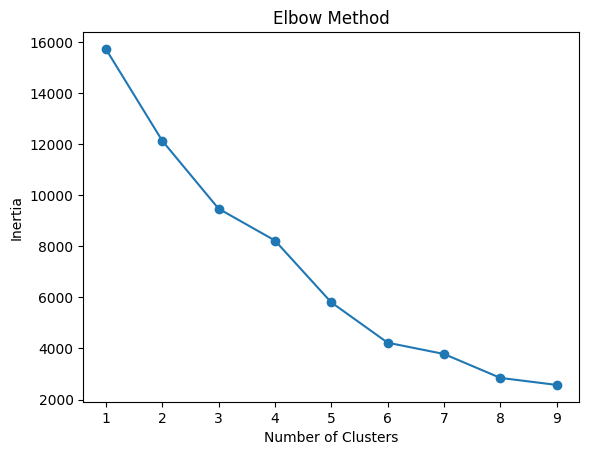

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

After k = 3, the curve starts flattening, meaning adding more clusters doesn’t improve much.

## Apply K-Means

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df[["SalePrice","LandSF","TotalFinishedArea","Cluster"]].head()

,SalePrice,LandSF,TotalFinishedArea,Cluster
0,259000.0,6000.0,1092.0,2
1,208000.0,6000.0,936.0,2
2,125000.0,6000.0,1111.0,2
3,177000.0,5040.0,1684.0,2
4,188000.0,6000.0,900.0,2


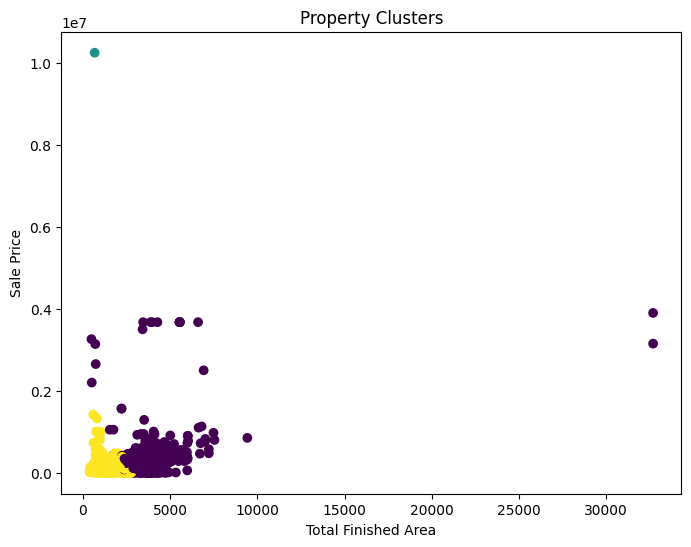

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df["TotalFinishedArea"], df["SalePrice"], c=df["Cluster"], cmap="viridis")

plt.xlabel("Total Finished Area")
plt.ylabel("Sale Price")
plt.title("Property Clusters")

plt.show()

Cluster Insight

a) Three distinct property groups
K-Means divided the properties into 3 clusters, representing different segments of the housing market.

b) Cluster 1 – High-value properties
A small number of properties have very high prices and large areas. These appear as outliers in the upper region of the plot.

c) Cluster 2 – Mid-range properties
Most properties fall in the middle price range with moderate house sizes, representing the typical residential market.

d) Cluster 3 – Lower-priced properties
Some properties have smaller finished areas and lower prices, representing affordable or smaller homes.

e) Business insight
This segmentation helps identify different property market segments, which can support pricing strategies, investment decisions, and targeted real estate marketing.

## the $10M property is dominating in the cluster (the one we identidied with time series), so maybe we can remove it for cluster analysis and see what happens 

In [26]:
df_clean = df[df["SalePrice"] < 2000000]

In [30]:
features = df_clean[["SalePrice", "LandSF", "TotalFinishedArea", "PricePerSqft"]]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df_clean["Cluster"] = kmeans.fit_predict(scaled_features)

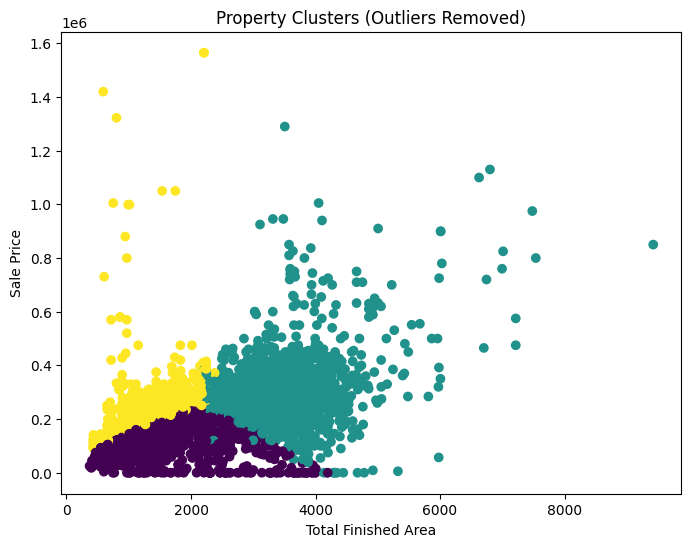

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(df_clean["TotalFinishedArea"], df_clean["SalePrice"], 
            c=df_clean["Cluster"], cmap="viridis")

plt.xlabel("Total Finished Area")
plt.ylabel("Sale Price")
plt.title("Property Clusters (Outliers Removed)")

plt.show()

### Cluster profile
interpret each cluster numerically.

In [43]:
df_clean.groupby("Cluster")[["SalePrice","LandSF","TotalFinishedArea","PricePerSqft"]].mean()

,SalePrice,LandSF,TotalFinishedArea,PricePerSqft
Cluster,,,,
0,105609.224425,6907.660920,1471.916962,81.925981
1,310528.153317,8267.645768,3467.033297,91.673514
2,246649.396369,7146.835129,1326.031806,198.525048


### Cluster Profile Insight

a) Cluster 0 – Lower-value properties
These properties have the lowest average sale price (~$105K) and moderate house sizes (~1472 sq ft).
They also have the lowest price per square foot (~$82), indicating more affordable housing.

b) Cluster 1 – Large premium properties
This cluster contains the largest homes (~3467 sq ft) and highest average sale price (~$310K).
These represent large, higher-value residential properties in the market.

c) Cluster 2 – Mid-sized high-value homes
These homes have smaller finished areas (~1326 sq ft) but a much higher price per square foot (~$198).
This suggests smaller but more expensive properties, likely located in more desirable areas.

d) Market segmentation insight
The clustering reveals three housing market segments:

affordable homes

large premium houses

compact but high-value properties

This segmentation helps identify different pricing structures in the real estate market.

In [47]:
df_clean.to_csv("property_clusters_extremePrice_removed.csv", index=False)